# UNO Project Results

This notebook summarizes the final pipeline as a short report. It covers:
- CNN training/loading,
- CNN performance on the symbol dataset,
- one-frame examples of symbol prediction,
- the logic used to delete duplicated card detections,
- token attribution, center-card attribution, player-card attribution,
- one full pipeline run on a frame.


## 1. Setup

We import the project modules and define the main paths used in the rest of the notebook.


In [12]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd() / 'project' if (Path.cwd() / 'project').exists() else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from cnn import DEFAULT_MODEL_PATH, Classifier
from notebook_utils import (
    build_pipeline_debug,
    ensure_model,
    evaluate_model,
    find_frame_with_duplicate_collapse,
    plot_confusion_matrix,
    plot_history,
    show_duplicate_collapse,
    show_patch_predictions,
    show_pipeline_assignments,
    show_token_assignment,
)

MODEL_PATH = PROJECT_DIR / 'symbol_cnn.pt'
HISTORY_PATH = PROJECT_DIR / 'symbol_cnn_history.json'
TEST_IMAGES_DIR = PROJECT_DIR / 'iapr-26-uno-vision-challenge' / 'test_images'

print('Project dir:', PROJECT_DIR)
print('Model path:', MODEL_PATH)
print('History path:', HISTORY_PATH)


Project dir: c:\Users\Utilisateur\Code\IAPR_gr69\project
Model path: c:\Users\Utilisateur\Code\IAPR_gr69\project\symbol_cnn.pt
History path: c:\Users\Utilisateur\Code\IAPR_gr69\project\symbol_cnn_history.json


## 2. Train the CNN if needed

The notebook trains the CNN only if the checkpoint does not already exist. If the model is already present, it is reused directly.


In [13]:
model_path, history_path, history, trained_now = ensure_model(
    model_path=MODEL_PATH,
    history_path=HISTORY_PATH,
    device='auto',
)

print('Model created in this notebook run:', trained_now)
print('Model exists:', model_path.exists())
print('History available:', history is not None)


Model created in this notebook run: False
Model exists: True
History available: True


## 3. CNN performance on the symbol dataset

We evaluate the saved model on the validation split (`validation.json`) and display standard classification metrics.


In [14]:
metrics, confusion_matrix, idx_to_class = evaluate_model(model_path=MODEL_PATH, device='auto')
metrics


{'accuracy': 1.0, 'macro_f1': 1.0, 'weighted_f1': 1.0}

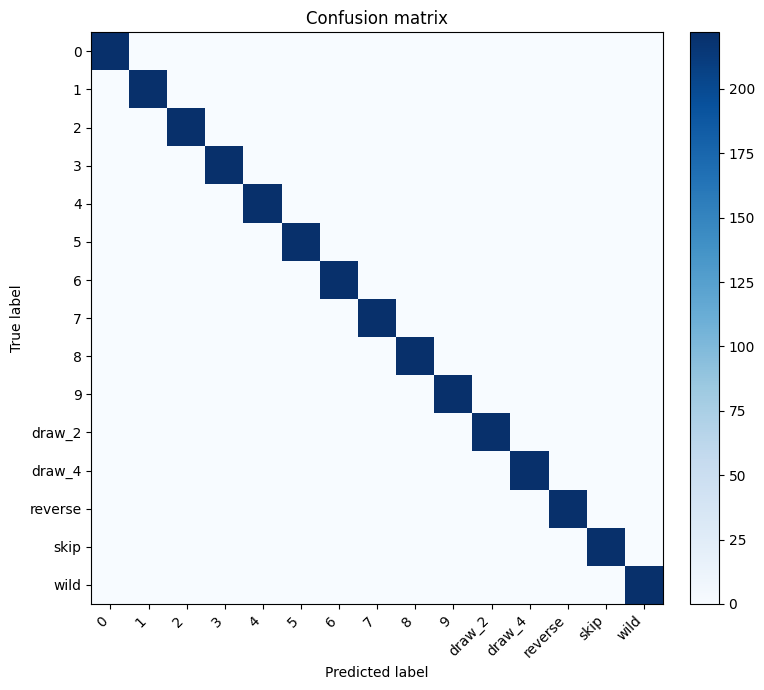

In [15]:
plot_confusion_matrix(confusion_matrix, idx_to_class)
plt.show()


### Training curves

If training history is available, we display the evolution of training and validation accuracy/loss over epochs.


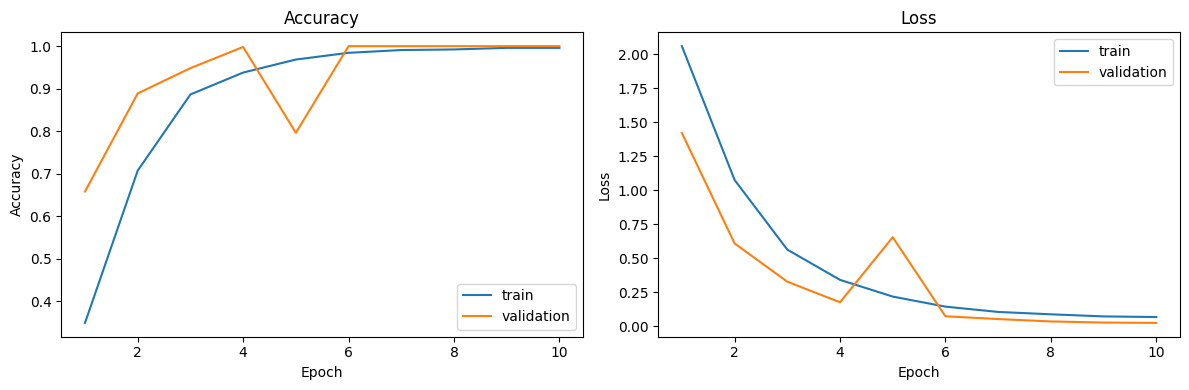

In [16]:
plot_history(history)
plt.show()


## 4. Run the CNN on one frame

The segmentation module first extracts symbol patches from one image, then the CNN classifies each patch. The figures below show example patches and the predicted labels/confidences.


Example frame: L1000793.jpg


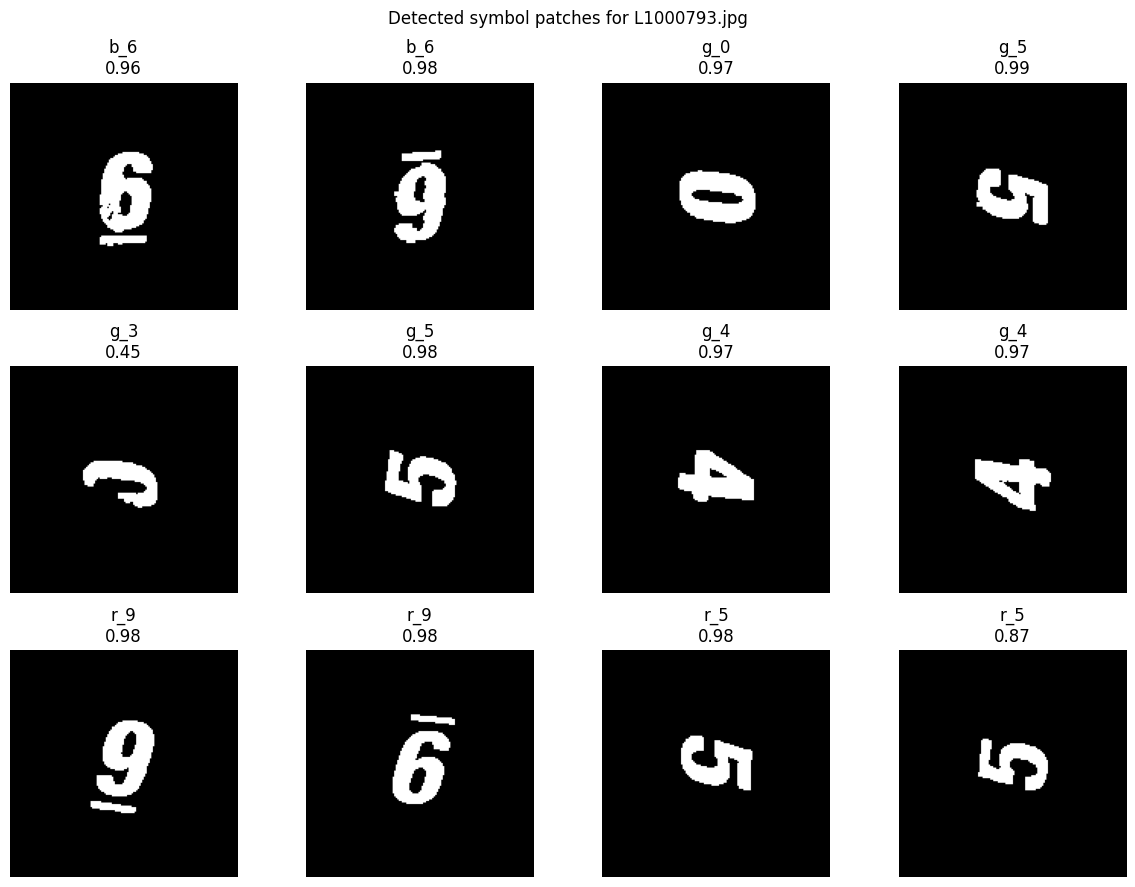

In [17]:
classifier = Classifier(MODEL_PATH, device='auto')
example_frame = sorted(TEST_IMAGES_DIR.glob('*.jpg'))[0]
print('Example frame:', example_frame.name)
debug_example = show_patch_predictions(example_frame, classifier)
plt.show()


## 5. Attribution of the central card and the player cards

After symbol classification, the pipeline first assigns detections to the center pile or to one of the four players. The cards closest to the image center are treated as center-pile candidates. The most confident center candidate becomes the central card, while the remaining detections are clustered and assigned to the players.


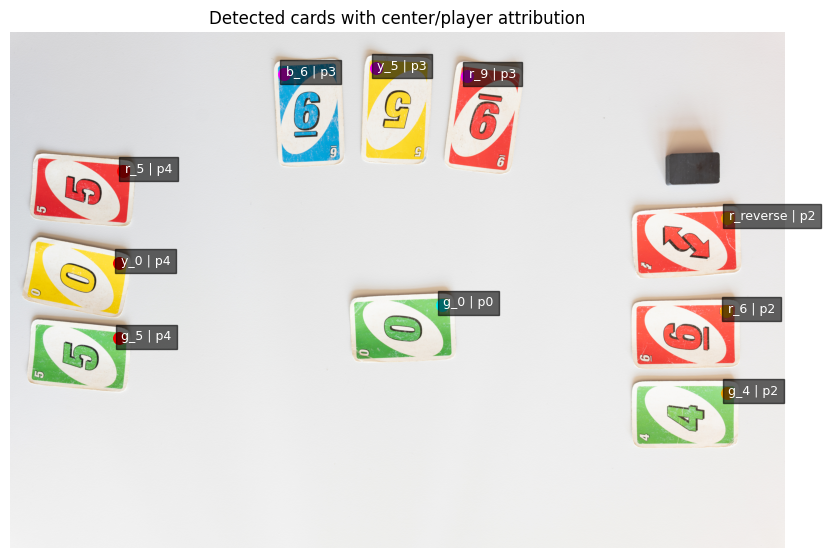

{'image_id': 'L1000793',
 'center_card': 'g_0',
 'active_player': 'p2',
 'player_1_cards': 'EMPTY',
 'player_2_cards': 'r_reverse;r_6;g_4',
 'player_3_cards': 'b_6;y_5;r_9',
 'player_4_cards': 'r_5;y_0;g_5'}

In [18]:
show_pipeline_assignments(debug_example, show_image=True, remove_duplicates=True)
plt.show()
debug_example['row']


## 6. Attribution of the token to a player

Once card detections have been assigned, the token center is detected by the segmentation pipeline. The active player is then obtained by assigning the token to the nearest player anchor position (bottom/right/top/left).


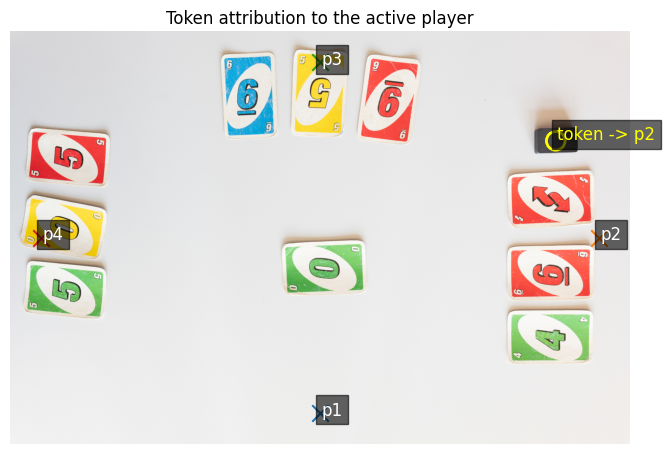

Active player: p2


In [19]:
show_token_assignment(debug_example)
plt.show()
print('Active player:', debug_example['active_player'])

## 7. Logic used to delete duplicated card detections

The duplicate-card deletion is applied after the player cards have been assigned. If two detections of the same card label are separated by the expected duplicate distance, one is removed so that a single physical card is counted only once.

The next cells search for one frame where this correction happens and print the card lists before and after deletion.


In [20]:
duplicate_frame, duplicate_debug = find_frame_with_duplicate_collapse(TEST_IMAGES_DIR, classifier, limit=159)
print('Duplicate example frame:', None if duplicate_frame is None else duplicate_frame.name)


Duplicate example frame: L1000793.jpg


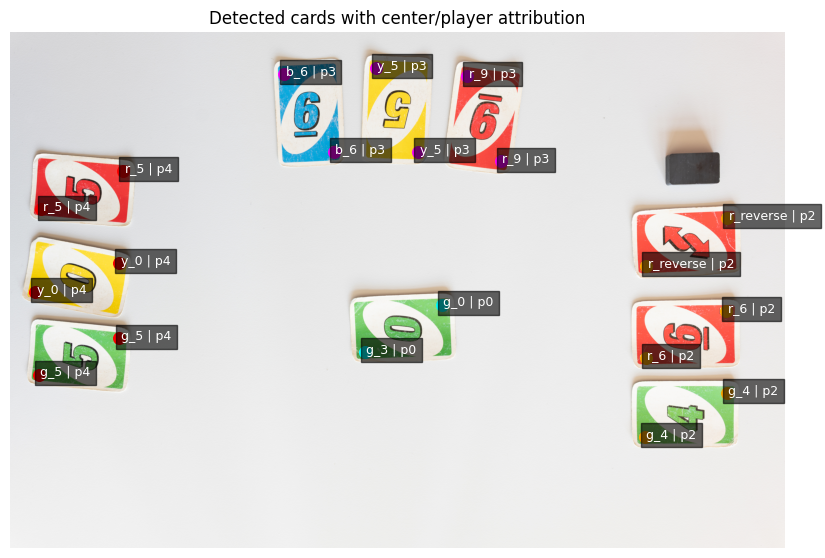

Player 1
  before: ['EMPTY']
  after:  ['EMPTY']
Player 2
  before: ['r_reverse', 'r_reverse', 'r_6', 'r_6', 'g_4', 'g_4']
  after:  ['r_reverse', 'r_6', 'g_4']
Player 3
  before: ['b_6', 'b_6', 'y_5', 'y_5', 'r_9', 'r_9']
  after:  ['b_6', 'y_5', 'r_9']
Player 4
  before: ['r_5', 'r_5', 'y_0', 'y_0', 'g_5', 'g_5']
  after:  ['r_5', 'y_0', 'g_5']


In [21]:
if duplicate_debug is not None:
    show_pipeline_assignments(duplicate_debug)
    plt.show()
    show_duplicate_collapse(duplicate_debug)
else:
    print('No duplicate-collapse example was found in the scanned frames.')


## 8. One full pipeline run on a frame

This final example shows the complete output of the pipeline for one frame: detected symbols, player assignment, center card, active player, and the final csv row.


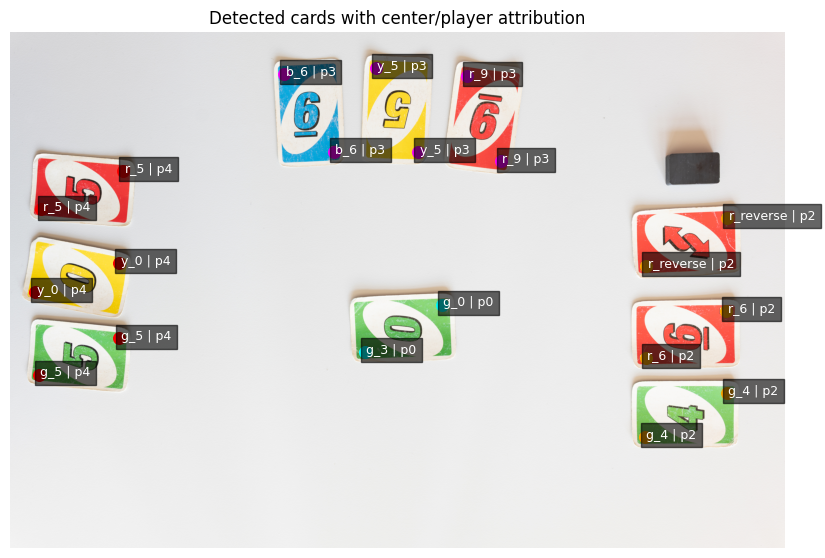

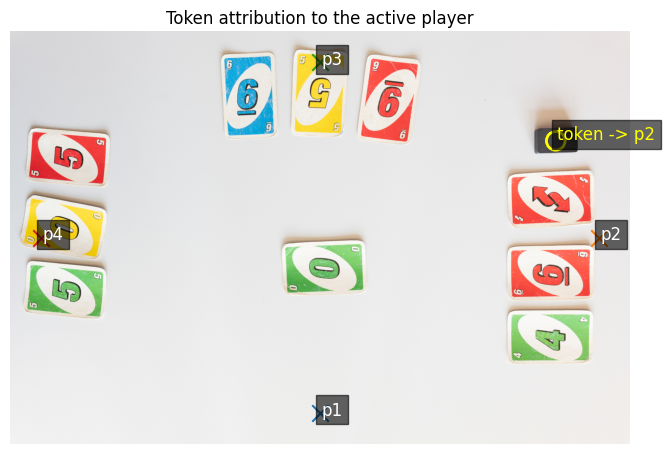

{'image_id': 'L1000793',
 'center_card': 'g_0',
 'active_player': 'p2',
 'player_1_cards': 'EMPTY',
 'player_2_cards': 'r_reverse;r_6;g_4',
 'player_3_cards': 'b_6;y_5;r_9',
 'player_4_cards': 'r_5;y_0;g_5'}

In [22]:
full_debug = build_pipeline_debug(example_frame, classifier)
show_pipeline_assignments(full_debug)
plt.show()
show_token_assignment(full_debug)
plt.show()
full_debug['row']